# Spam Message Detection Model

### Import Dependencies

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


### Load Data and Process Data

In [104]:
spam_data = pd.read_csv('data/spamMessage.csv')
spam_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [105]:
spam_data.shape

(5572, 2)

In [106]:
spam_data.describe()

,Category,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [107]:
# Check for empty values
spam_data.isnull().sum()

Category    0
Message     0
dtype: int64

In [108]:
spam_data['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [109]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # Lower all characters
    text = text.lower()
    # Remove all punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Turn the text into a list of words
    words = text.split()
    # Remove all stop words (eg: the, is, at, etc.)
    words = [word for word in words if word not in stop_words]
    # Stem the words (eg: running -> run)
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

#Testing the clean_text function
print(clean_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."))

im gonna home soon dont want talk stuff anymor tonight k ive cri enough today


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nathan0629/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [110]:
spam_data['Cleaned_Message'] = spam_data['Message'].apply(clean_text)
spam_data.head()

,Category,Message,Cleaned_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


### Vectorize Text (Using TF-IDF Vectorizer)

In [111]:
# Initialize the TFIDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
X = vectorizer.fit_transform(spam_data['Cleaned_Message'])
spam_data['Label'] = spam_data['Category'].map({'ham': 0, 'spam': 1})
Y = spam_data['Label']
# 5000 features, 5572 rows of data
print(X.shape)
print(Y.shape)

(5572, 5000)
(5572,)


### Split Data for training

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.1, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 5014
Testing samples:  558


### Train Model

**Naive Bayes**

In [113]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
print("Naive Bayes done ✓")

Naive Bayes done ✓


**Logistic Regression**

In [114]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
print("Logistic Regression done ✓")

Logistic Regression done ✓


**Support Vector Machine (SVM)**

In [115]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
print("Support Vector Machine done ✓")



Support Vector Machine done ✓


**Random Forest**

In [116]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print("Random Forest done ✓")


Random Forest done ✓


**Decision Tree**

In [117]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
print("Decision Tree done ✓")



Decision Tree done ✓


## Evaluate Model

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Naive Bayes,0.9731,1.0000,0.8000,0.8889
Logistic Regression,0.9695,1.0000,0.7733,0.8722
SVM,0.9785,1.0000,0.8400,0.9130
Random Forest,0.9767,1.0000,0.8267,0.9051
Decision Tree,0.9588,0.8611,0.8267,0.8435


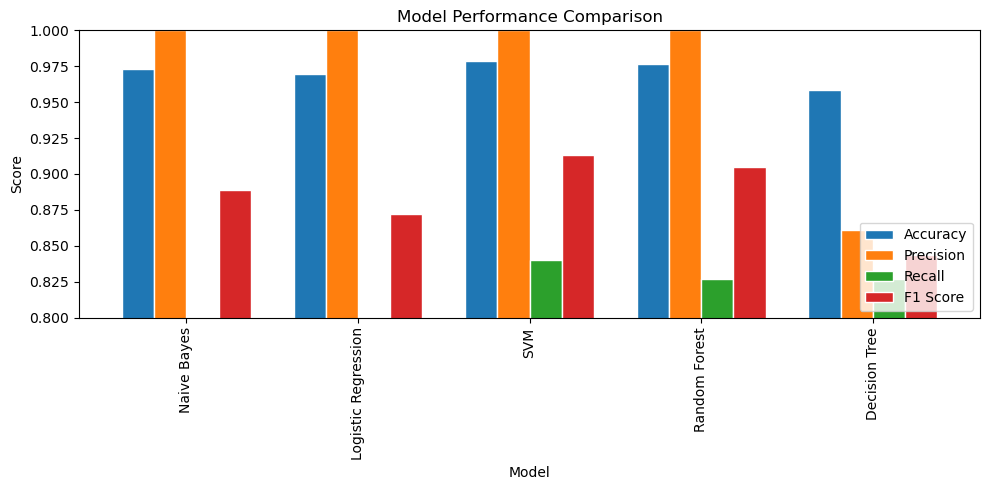

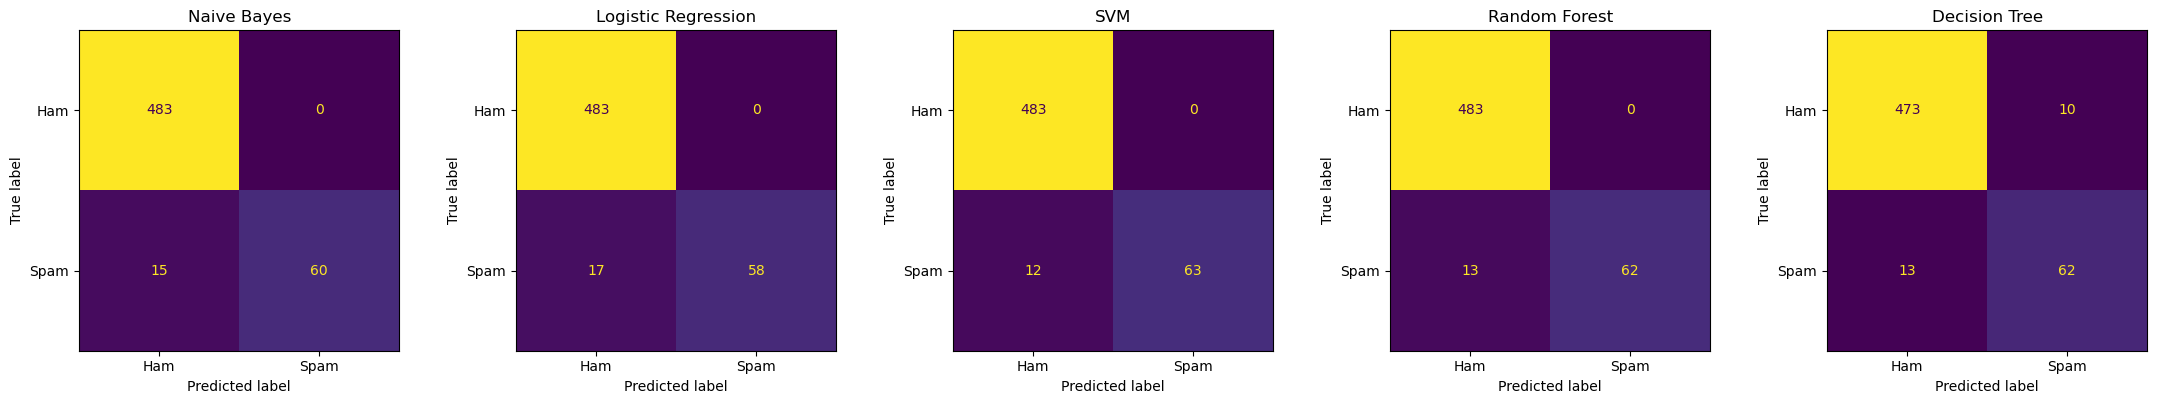

In [118]:
def evaluate_model(name, y_true, preds):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1 Score': f1_score(y_true, preds),
    }

results = [
    ("Naive Bayes", nb_preds),
    ("Logistic Regression", lr_preds),
    ("SVM", svm_preds),
    ("Random Forest", rf_preds),
    ("Decision Tree", dt_preds),
]

df_metrics = pd.DataFrame([evaluate_model(n, y_test, p) for n, p in results]).set_index('Model')
display(df_metrics.style.format("{:.4f}").highlight_max(axis=0, props='font-weight:bold; background-color:#c8e6c9;'))

ax = df_metrics.plot.bar(figsize=(10, 5), edgecolor='white', width=0.75)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, preds) in zip(axes, results):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=['Ham', 'Spam'], ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### **SVM** is the best among the models

**Tune** and Improve SVM model

In [119]:
#Pipeline
X_train_text, X_test_text, y_train2, y_test2 = train_test_split(
    spam_data['Cleaned_Message'], Y, stratify=Y, test_size=0.1, random_state=42
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ('svm',   SVC(kernel='linear', class_weight='balanced', random_state=42))
])

pipeline.fit(X_train_text, y_train2)
preds = pipeline.predict(X_test_text)

evaluate_model("SVM Pipeline", y_test2, preds)



{'Model': 'SVM Pipeline',
 'Accuracy': 0.9731182795698925,
 'Precision': 0.9166666666666666,
 'Recall': 0.88,
 'F1 Score': 0.8979591836734694}

In [120]:
#Grid Search
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm',   SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42))
])

param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'svm__C'             : [0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,           # 5-fold cross validation
    scoring='f1',   # optimise for F1
    n_jobs=-1,      # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_text, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:  ", grid_search.best_score_)

# Evaluate best model on test set
best_preds = grid_search.predict(X_test_text)
evaluate_model("Tuned SVM", y_test, best_preds)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'svm__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}
Best F1 score:   0.9278876034562147


{'Model': 'Tuned SVM',
 'Accuracy': 0.974910394265233,
 'Precision': 0.9178082191780822,
 'Recall': 0.8933333333333333,
 'F1 Score': 0.9054054054054054}

### Test the Model

In [121]:
def predict_message(message):
    # Clean the message using your existing function
    cleaned = clean_text(message)
    
    # Use the best pipeline from GridSearchCV
    prediction = grid_search.predict([message])[0]
    probability = grid_search.best_estimator_.predict_proba([message])[0]
    
    label = "SPAM" if prediction == 1 else "HAM"
    confidence = probability[prediction] * 100
    
    print(f"Message   : {message}")
    print(f"Result    : {label}")
    print(f"Confidence: {confidence:.1f}%")
    print()

test_messages = [
    "FREE entry! Win a £1000 prize, call now 08712345678!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been compromised. Click here to verify.",
    "Can you pick up some milk on the way home?",
    "Congratulations! You have been selected for a cash reward!",
    "I'll be late to the meeting, sorry!",
]

for msg in test_messages:
    predict_message(msg)

Message   : FREE entry! Win a £1000 prize, call now 08712345678!
Result    : SPAM
Confidence: 100.0%

Message   : Hey, are we still meeting for lunch tomorrow?
Result    : HAM
Confidence: 100.0%

Message   : URGENT! Your account has been compromised. Click here to verify.
Result    : HAM
Confidence: 89.4%

Message   : Can you pick up some milk on the way home?
Result    : HAM
Confidence: 100.0%

Message   : Congratulations! You have been selected for a cash reward!
Result    : SPAM
Confidence: 81.6%

Message   : I'll be late to the meeting, sorry!
Result    : HAM
Confidence: 99.0%

